# Customer Segmentation

## Objective

The objective of this notebook is to segment customers into distinct groups based on their purchasing behavior using the RFM (Recency, Frequency, Monetary) model and the K-Means clustering algorithm.

The identified customer segments help businesses understand customer behavior, improve marketing strategies, and personalize customer engagement.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
rfm = pd.read_csv("../data/processed/customer_rfm.csv")

In [3]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,12,77556.46
1,12347.0,2,8,4921.53
2,12348.0,75,5,2019.40
3,12349.0,19,4,4428.69
4,12350.0,310,1,334.40


In [4]:
rfm.info()

<class 'pandas.DataFrame'>
RangeIndex: 5878 entries, 0 to 5877
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  5878 non-null   float64
 1   Recency     5878 non-null   int64  
 2   Frequency   5878 non-null   int64  
 3   Monetary    5878 non-null   float64
dtypes: float64(2), int64(2)
memory usage: 183.8 KB


In [5]:
rfm.isnull().sum()

CustomerID    0
Recency       0
Frequency     0
Monetary      0
dtype: int64

## Feature Scaling

The RFM features have different value ranges. Therefore, feature scaling is performed using StandardScaler before applying the K-Means clustering algorithm. This ensures that each feature contributes equally during clustering.

In [6]:
features = rfm[["Recency", "Frequency", "Monetary"]]

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

scaled_df = pd.DataFrame(
    scaled_features,
    columns=["Recency", "Frequency", "Monetary"]
)

scaled_df.head()

,Recency,Frequency,Monetary
0,0.595584,0.438998,5.166378
1,-0.952279,0.131502,0.136127
2,-0.603532,-0.099120,-0.064857
3,-0.871064,-0.175994,0.101996
4,0.519146,-0.406616,-0.181549


## Elbow Method

The Elbow Method is used to determine the optimal number of clusters for K-Means clustering. It calculates the Within Cluster Sum of Squares (WCSS) for different values of K and identifies the point where adding more clusters provides diminishing improvements.

In [7]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(scaled_features)
    
    wcss.append(kmeans.inertia_)

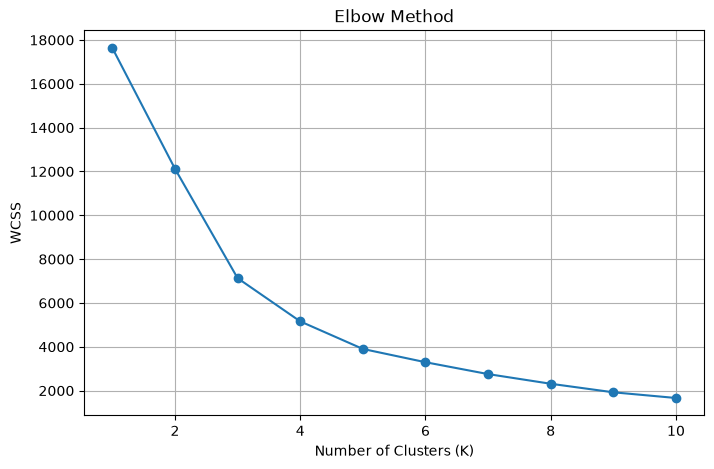

In [8]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker="o")

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")

plt.grid(True)

plt.show()

## K-Means Clustering

Based on the Elbow Method, the optimal number of clusters is chosen as **4**. The K-Means algorithm is applied to segment customers using the standardized RFM features.

In [9]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(scaled_features)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346.0,326,12,77556.46,0
1,12347.0,2,8,4921.53,0
2,12348.0,75,5,2019.40,0
3,12349.0,19,4,4428.69,0
4,12350.0,310,1,334.40,1


In [10]:
rfm["Cluster"].value_counts().sort_index()

Cluster
0    3838
1    1998
2       4
3      38
Name: count, dtype: int64

## Cluster Summary

The average RFM values are calculated for each cluster to understand customer behavior and characteristics.

In [11]:
cluster_summary = (
    rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]]
       .mean()
       .round(2)
)

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,67.05,7.27,2921.08
1,463.03,2.21,748.54
2,3.50,212.50,428612.00
3,24.26,100.13,77728.27


## Assign Business Labels

The generated clusters are assigned descriptive labels based on their average RFM characteristics to improve interpretability.

In [12]:
cluster_names = {
    0: "Regular Customers",
    1: "At-Risk Customers",
    2: "VIP Customers",
    3: "Loyal Customers"
}

rfm["CustomerSegment"] = rfm["Cluster"].map(cluster_names)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster,CustomerSegment
0,12346.0,326,12,77556.46,0,Regular Customers
1,12347.0,2,8,4921.53,0,Regular Customers
2,12348.0,75,5,2019.40,0,Regular Customers
3,12349.0,19,4,4428.69,0,Regular Customers
4,12350.0,310,1,334.40,1,At-Risk Customers


In [13]:
rfm["CustomerSegment"].value_counts()

CustomerSegment
Regular Customers    3838
At-Risk Customers    1998
Loyal Customers        38
VIP Customers           4
Name: count, dtype: int64

In [14]:
rfm.to_csv("../data/processed/customer_segments.csv", index=False)

## Customer Segment Distribution

The following chart shows the number of customers in each customer segment.

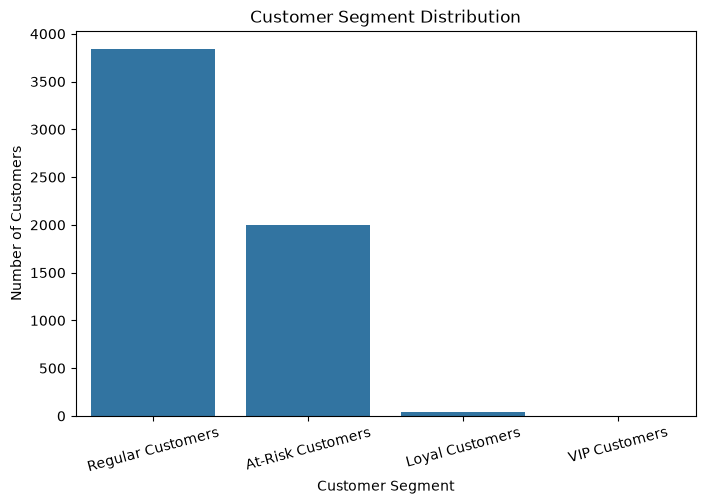

In [15]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=rfm,
    x="CustomerSegment",
    order=rfm["CustomerSegment"].value_counts().index
)

plt.title("Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.xticks(rotation=15)

plt.show()

## Monetary Value Across Customer Segments

This boxplot compares the spending behavior of different customer segments.

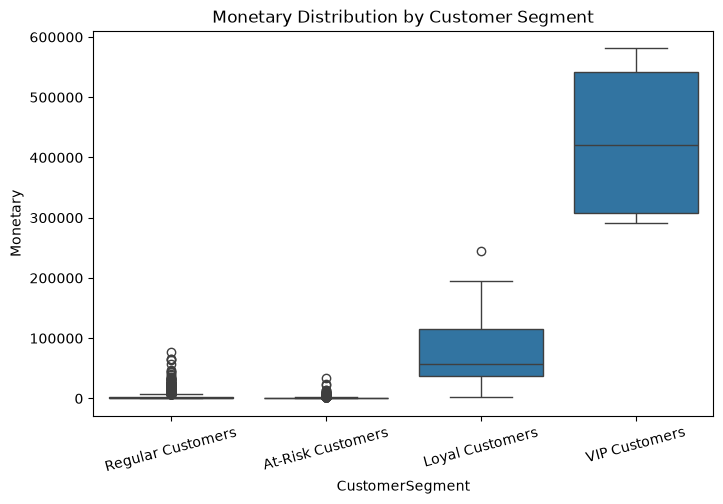

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=rfm,
    x="CustomerSegment",
    y="Monetary"
)

plt.title("Monetary Distribution by Customer Segment")
plt.xticks(rotation=15)

plt.show()

## Customer Segments Visualization

Scatter plot showing customer segments based on Recency and Monetary values.

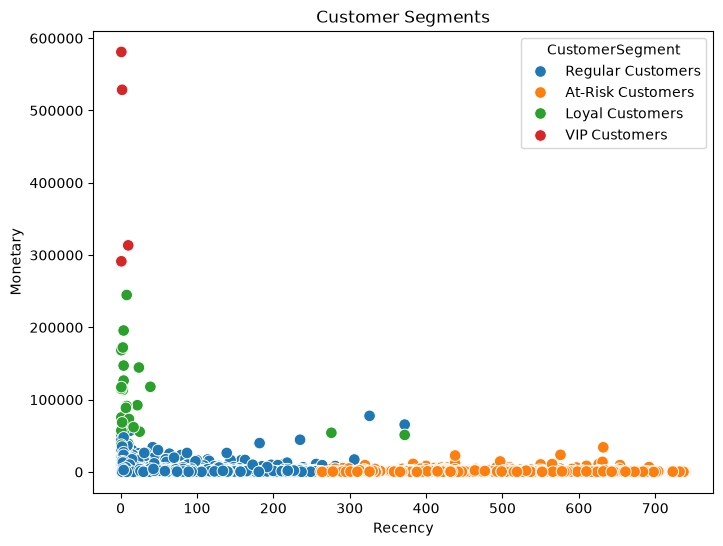

In [17]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Monetary",
    hue="CustomerSegment",
    s=70
)

plt.title("Customer Segments")
plt.xlabel("Recency")
plt.ylabel("Monetary")

plt.show()

## Business Insights

- **Regular Customers** form the largest customer group and contribute consistent revenue. Marketing campaigns can encourage them to become loyal customers.

- **At-Risk Customers** have high recency values, indicating they have not purchased recently. Personalized offers and reminder campaigns can help re-engage them.

- **Loyal Customers** purchase frequently and generate significant revenue. Loyalty rewards and exclusive promotions can strengthen their relationship with the business.

- **VIP Customers** represent a very small portion of the customer base but contribute exceptionally high monetary value. They should receive premium support and personalized services to maximize retention.

In [18]:
rfm.to_csv("../data/processed/customer_segments.csv", index=False)